In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from mujoco_playground import registry
from trajax import optimizers, integrators
import mediapy as media

### Environment setup

In [2]:
# create enviroment
env = registry.load('PendulumSwingup')
env_cfg = registry.get_default_config('PendulumSwingup')

jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

T = env_cfg.episode_length
action_size = env.action_size

### Rollout

100%|██████████| 1001/1001 [00:00<00:00, 1461.44it/s]



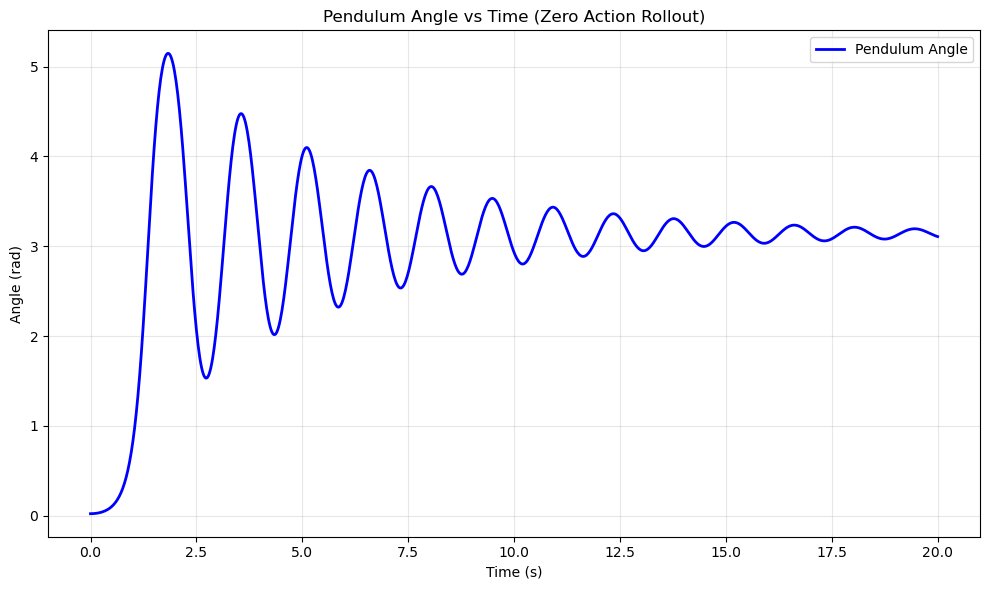

In [28]:
f = 0.5  # frequency for sinusoidal actions
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)  # <-- you need this before the loop
rollout = [state]

for i in range(env_cfg.episode_length):
    action = []
    for j in range(env.action_size):
        action.append(
            0.0 #jnp.sin(state.data.time * 2 * jnp.pi * f + j * 2 * jnp.pi / env.action_size)
        )
    action = jnp.array(action)
    #print(type(action))
    state = jit_step(state, action)
    rollout.append(state)

# ----------------------------
# 4️⃣ Render rollout as video
# ----------------------------
frames = env.render(rollout)

# ----------------------------
# Plot pendulum angle over time
# ----------------------------
# Extract angles from the rollout
angles = []
for state in rollout:
    theta = state.data.qpos[env._hinge_qposadr]
    angles.append(theta)

# Create time array
dt = env._config.ctrl_dt
time_steps = jnp.arange(len(angles)) * dt

# Plot the angle trajectory
plt.figure(figsize=(10, 6))
plt.plot(time_steps, angles, 'b-', linewidth=2, label='Pendulum Angle')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Pendulum Angle vs Time (Zero Action Rollout)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
#plt.imshow(frames[0])
media.show_video(frames, fps=1.0 / env.dt)

This browser does not support the video tag.


### TO solve using ilqr

In [30]:
def state_to_array(state):
    theta = state.data.qpos[env._hinge_qposadr]
    theta_dot = state.data.qvel[env._hinge_qveladr]
    return jnp.array([theta, theta_dot])

def array_to_state(x, ref_state):
    data = ref_state.data.replace(
        qpos=ref_state.data.qpos.at[env._hinge_qposadr].set(x[0]),
        qvel=ref_state.data.qvel.at[env._hinge_qveladr].set(x[1])
    )
    return ref_state.replace(data=data)

# dynamics func
def dynamics_func(x, u, t):
    s = array_to_state(x, state)
    next_s = jit_step(s, u)
    return state_to_array(next_s)

# cost func
goal = jnp.array([0, 0.])
Q = jnp.diag(jnp.array([100., 1.]))
R = jnp.array([[0.1]])

def cost_func(x, u, t):
    delta = x - goal
    return delta @ Q @ delta + u @ R @ u

In [31]:
T = 300
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
x0 = state_to_array(state)
U_init = jnp.zeros((T, env.action_size))

X_opt, U_opt, *_ = optimizers.ilqr(
    cost_func, dynamics_func, x0, U_init, maxiter=100, psd_delta=1e-4
)

final_state = X_opt[-1]
print("Final theta:", final_state[0])
print("Final theta_dot:", final_state[1])

Final theta: 2.416502
Final theta_dot: -0.8921212


In [32]:
# Apply the optimal control actions to the pendulum

rng = jax.random.PRNGKey(0)
state = jit_reset(rng)  # <-- you need this before the loop
rollout = [state]

print("Applying optimal actions from U_opt...")
print(f"U_opt shape: {U_opt.shape}")

# Use the optimal actions instead of sinusoidal actions
for i in range(min(len(U_opt), env_cfg.episode_length)):
    # Use the optimal action from U_opt
    action = jnp.array(U_opt[i])
    state = jit_step(state, action)
    rollout.append(state)

frames = env.render(rollout)

media.show_video(frames, fps=1.0 / env.dt)

Applying optimal actions from U_opt...
U_opt shape: (300, 1)


100%|██████████| 301/301 [00:00<00:00, 1196.30it/s]



This browser does not support the video tag.


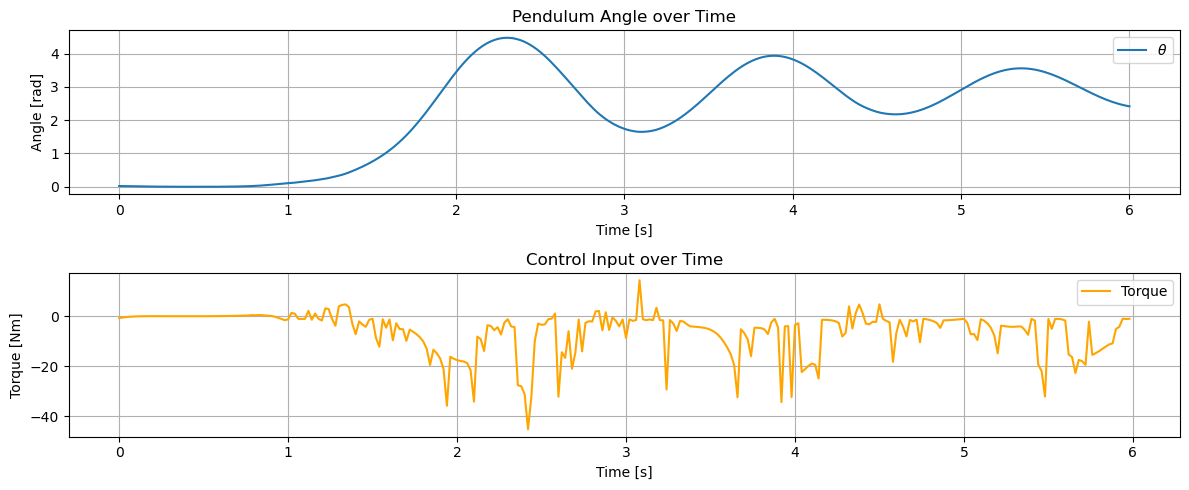

In [33]:
# Extract theta from X_opt
theta = X_opt[:, 0]
u = U_opt[:, 0]

# Time axis
dt = env._config.ctrl_dt
time = jnp.arange(T+1) * dt

plt.figure(figsize=(12,5))

# Theta
plt.subplot(2,1,1)
plt.plot(time, theta, label=r"$\theta$")
plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("Pendulum Angle over Time")
plt.grid(True)
plt.legend()

# Control
plt.subplot(2,1,2)
plt.plot(time[:-1], u, label="Torque", color="orange")  # U_opt is usually T x action_dim
plt.xlabel("Time [s]")
plt.ylabel("Torque [Nm]")
plt.title("Control Input over Time")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

References:
1. trajax: https://github.com/google/trajax/blob/main/notebooks/l4dc/Car2D.ipynb
2. mujoco playground: https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/dm_control_suite.ipynb